# NB03 — WTI Volatility: Pipeline de Sentimiento FinBERT
## Recolección · Scoring · Alineación Temporal · Exportación

**Proyecto:** Benchmark GARCH / LSTM / Híbrido para detección de volatilidad extrema WTI  
**Input:** GDELT Project (gratuito) + EIA Weekly Reports (respaldo)  
**Output:** `wti_sentiment_finbert.csv` → usado en NB02 Parte V

---

## Índice
0. Instalación y configuración  
1. Descarga de titulares (GDELT)  
2. Respaldo: EIA Weekly Reports  
3. Limpieza y deduplicación  
4. Scoring con FinBERT  
5. Agregación diaria  
6. Alineación temporal (shift anti-leakage)  
7. Análisis exploratorio del sentimiento  
8. Exportación

---

> **Nota sobre data leakage**: El sentimiento del día t se desplaza 1 día hacia adelante
> antes de mergearse con las features de volatilidad. El modelo en NB02 usa
> `sentiment_score(t-1)` para predecir `is_extreme(t+1)` — no hay información del futuro.

## 0. Instalación y Configuración

In [1]:
# gdeltdoc: cliente oficial de GDELT Project
# transformers: FinBERT (ProsusAI/finbert)
# torch: backend para inferencia FinBERT
# sentencepiece: tokenizador BERT

#  0.1 Instalación de dependencias
# Fijar pandas a versión compatible con Colab antes de instalar gdeltdoc
!pip install "pandas==2.2.2" gdeltdoc transformers torch sentencepiece -q

# Verificar versiones
import pandas as pd
import transformers
print(f"pandas      : {pd.__version__}   (requerido: <3.0.0)")
print(f"transformers: {transformers.__version__}")

# Guard de versión
assert pd.__version__.startswith('2.'), \
    f"pandas {pd.__version__} incompatible — REINICIA EL RUNTIME (Entorno de ejecución > Reiniciar sesión) y vuelve a ejecutar."
print("Dependencias OK ✓")

pandas      : 2.2.2   (requerido: <3.0.0)
transformers: 5.0.0
Dependencias OK ✓


In [2]:
# ─── 0.2 Imports ──────────────────────────────────────────────
import sys, os, json, random, re, time, warnings, pickle
from datetime import datetime, timedelta
from pathlib import Path

import numpy  as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.6f}'.format)

#  Estilo IEEE
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'legend.fontsize': 9,
    'figure.dpi': 300, 'savefig.dpi': 300,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': ':',
    'axes.edgecolor': 'black', 'axes.linewidth': 0.8,
})

RANDOM_SEED = 42
random.seed(RANDOM_SEED)      # Python — para shuffle si lo hay
np.random.seed(RANDOM_SEED)   # NumPy — para operaciones de muestreo
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)  # orden interno Python
import torch
torch.manual_seed(RANDOM_SEED)

print('Imports OK')
print(f'Python  : {sys.version.split()[0]}')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')

Imports OK
Python  : 3.12.12
Pandas  : 2.2.2
NumPy   : 2.0.2


In [3]:
# -- Importar utilidades de figura (A4/Letter) --------------------------------
import sys as _sys_fig
_utils_colab = '/content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/utils'
_utils_local = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', 'utils'))
for _p in [_utils_colab, _utils_local]:
    if os.path.isdir(_p) and _p not in _sys_fig.path:
        _sys_fig.path.insert(0, _p)
try:
    from figure_utils import fig_size, save_fig, apply_thesis_style
    apply_thesis_style('A4')
except ImportError:
    import warnings as _w
    def fig_size(layout='full', fmt='A4', aspect=0.618):
        tw = 6.11 if fmt == 'A4' else 6.34
        th = 9.73 if fmt == 'A4' else 9.04
        opts = {
            'full'  : (tw,      tw * aspect),
            'half'  : (tw / 2,  (tw / 2) * aspect),
            'wide'  : (tw,      tw * 0.45),
            '2x1'   : (tw,      tw * 0.50),
            '2x2'   : (tw,      tw * 0.75),
            '3x1'   : (tw,      tw * 0.38),
            'square': (tw,      tw),
            'tall'  : (tw,      min(tw * 1.40, th * 0.85)),
            'page'  : (tw,      th * 0.90),
        }
        return opts.get(layout, (tw, tw * aspect))
    def save_fig(fig, name, output_path='.', dpi=300, fmt='png', **kw):
        os.makedirs(output_path, exist_ok=True)
        p = os.path.join(output_path, f'{name}.{fmt}')
        fig.savefig(p, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f'  [OK] Guardada: {p}')
        return p
    _w.warn('[WARN] figure_utils.py no encontrado -- fallback inline activo.', ImportWarning)

In [4]:
# ─── 0.3 Colab / rutas ────────────────────────────────────────
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=False)
    BASE_PATH = "/content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos"
    NB03_PATH = "/content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/NB03_FinBERT"
    FIG_PATH  = f"{NB03_PATH}/Fig_NB03"
else:
    BASE_PATH = "."
    FIG_PATH  = "."

os.makedirs(FIG_PATH, exist_ok=True)

CONFIG_PATH   = f"{BASE_PATH}/config_estudio_FINAL.json"
CSV_CLEAN     = f"{BASE_PATH}/wti_volatilidad_CLEAN.csv"
OUTPUT_SENT   = f"{NB03_PATH}/wti_sentiment_finbert.csv"
CACHE_RAW     = f"{NB03_PATH}/wti_gdelt_raw_2017_2026.csv"   # cache para no re-descargar

# Cargar config NB01
with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    config = json.load(f)

START_DATE = config['fechas']['start_date']   # 2000-01-01
END_DATE   = config['fechas']['end_date']     # 2026-02-28
TRAIN_END  = config['fechas']['train_end']    # 2018-12-31
VAL_START  = config['fechas']['val_start']    # 2019-01-02
VAL_END    = config['fechas']['val_end']      # 2020-12-31
TEST_START = config['fechas']['test_start']   # 2021-01-02

print(f'BASE_PATH : {BASE_PATH}')
print(f'Período   : {START_DATE} → {END_DATE}')
print('Config cargado ✓')

Mounted at /content/drive
BASE_PATH : /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos
Período   : 2000-01-01 → 2026-02-28
Config cargado ✓


---
## PARTE I — Descarga de Titulares (GDELT)

> **GDELT Project** (gdeltproject.org): base de datos global de noticias, gratuita y de acceso público.
> Indexa titulares de miles de medios en tiempo real desde 1979.
> API disponible vía `gdeltdoc` (Python) sin autenticación.
>
> **Estrategia de descarga**: queries por bloques de 3 meses para respetar
> los límites de la API (~250 artículos por query). El caché local evita
> re-descargas en ejecuciones posteriores.

In [5]:
# ─── 1.1 Configuración de queries GDELT ──────────────────────
from gdeltdoc import GdeltDoc, Filters

# Términos de búsqueda — cubren petróleo crudo WTI y mercados de energía
# Se usan términos en inglés porque GDELT indexa mayoría de medios en inglés
# NOTA: cada término = 1 request por bloque trimestral (~36 bloques 2017-2026)
SEARCH_TERMS = [
    'WTI crude oil',
    'crude oil price',
    'oil price volatility',
    'OPEC crude oil',
    'oil market',
]

# Dominios de noticias financieras de alta calidad
# (reducen ruido frente a blogs/tabloides)
DOMAINS = [
    'reuters.com',
    'bloomberg.com',
    'wsj.com',
    'ft.com',
    'cnbc.com',
    'marketwatch.com',
    'oilprice.com',
]

print('Términos de búsqueda configurados:')
for t in SEARCH_TERMS:
    print(f'  - {t}')
print(f'\nDominios preferidos: {len(DOMAINS)}')

Términos de búsqueda configurados:
  - WTI crude oil
  - crude oil price
  - oil price volatility
  - OPEC crude oil
  - oil market

Dominios preferidos: 7


In [6]:
# ─── 1.2 Descarga robusta por bloques trimestrales (GDELT) ────
# GDELT 2.0 tiene cobertura confiable desde 2017-01-01.
# Fechas anteriores se ajustan automáticamente.
# Rate limit manejado con backoff exponencial.

import time
from datetime import datetime, timezone

API_MIN_DATE    = pd.Timestamp("2017-01-01")
RATE_LIMIT_KEYS = ("ratelimit", "please limit requests", "too many requests")


def _quarter_blocks(start: str, end: str) -> list:
    """Genera bloques trimestrales en formato YYYY-MM-DD."""
    t0 = pd.Timestamp(start).normalize()
    t1 = pd.Timestamp(end).normalize()

    # Ajustar al rango real de GDELT 2.0
    if t0 < API_MIN_DATE:
        print(f"⚠  START_DATE {t0.date()} fuera de rango GDELT 2.0. "
              f"Ajustado a {API_MIN_DATE.date()}.")
        t0 = API_MIN_DATE

    # No consultar fechas futuras
    today = pd.Timestamp(datetime.now(timezone.utc).date())
    if t1 > today:
        t1 = today

    if t0 >= t1:
        raise ValueError(f"Rango inválido: {t0.date()} → {t1.date()}")

    blocks, cur = [], t0
    while cur < t1:
        nxt = min(cur + pd.DateOffset(months=3), t1)
        blocks.append((cur.strftime("%Y-%m-%d"), nxt.strftime("%Y-%m-%d")))
        cur = nxt
    return blocks


def _is_rate_limit(exc: Exception) -> bool:
    msg = repr(exc).lower()
    return any(k in msg for k in RATE_LIMIT_KEYS)


def _search_with_retry(gd, term, t_start, t_end,
                       max_retries=3, base_sleep=10.0):
    """Ejecuta una búsqueda GDELT con reintentos ante rate limit."""
    for attempt in range(max_retries + 1):
        try:
            f = Filters(keyword=term, start_date=t_start, end_date=t_end)
            return gd.article_search(f)
        except Exception as exc:
            if not _is_rate_limit(exc) or attempt == max_retries:
                print(f"  Error [{t_start}] '{term}': {repr(exc)}")
                return None
            wait = base_sleep * (2 ** attempt)
            print(f"  Rate limit [{t_start}] '{term}' → "
                  f"reintento {attempt+1}/{max_retries} en {wait:.0f}s")
            time.sleep(wait)
    return None


def download_gdelt(cache_path, search_terms, start_date, end_date,
                   sleep_s=6.0, max_retries=3,
                   base_sleep=10.0, block_pause=8.0):
    """
    Descarga artículos GDELT por bloques trimestrales con cache local.

    Parámetros
    ----------
    cache_path   : str   — ruta del CSV de cache
    search_terms : list  — términos de búsqueda
    start_date   : str   — fecha inicio (se ajusta a 2017-01-01 si es anterior)
    end_date     : str   — fecha fin
    sleep_s      : float — pausa entre requests (mín 5s por política GDELT)
    max_retries  : int   — reintentos ante rate limit
    base_sleep   : float — base del backoff exponencial (segundos)
    block_pause  : float — pausa adicional entre bloques trimestrales
    """
    # ── Cargar cache si existe ────────────────────────────────
    if os.path.exists(cache_path):
        print(f"Cache encontrado: {cache_path}")
        df = pd.read_csv(cache_path, parse_dates=["seendate"])
        print(f"  {len(df):,} artículos cargados")
        return df

    # ── Descarga ──────────────────────────────────────────────
    print("Iniciando descarga GDELT...")
    gd      = GdeltDoc()
    chunks  = []
    blocks  = _quarter_blocks(start_date, end_date)
    n       = len(blocks)
    terms   = list(search_terms)

    print(f"Bloques trimestrales: {n} | Términos: {len(terms)}")
    print(f"Período efectivo: {blocks[0][0]} → {blocks[-1][1]}\n")

    for i, (t0, t1) in enumerate(blocks, 1):
        block = []
        for term in terms:
            result = _search_with_retry(gd, term, t0, t1,
                                        max_retries, base_sleep)
            if result is not None and not result.empty:
                block.append(result)
            time.sleep(max(sleep_s, 5.0))   # nunca menos de 5s

        if block:
            chunks.append(pd.concat(block, ignore_index=True))

        if i % 5 == 0 or i == n:
            acc = sum(len(c) for c in chunks)
            print(f"  [{i:3d}/{n}] {t0} | acumulado: {acc:,} artículos")

        if block_pause > 0:
            time.sleep(block_pause)

    # ── Consolidar ────────────────────────────────────────────
    if not chunks:
        print("⚠  Sin artículos — verificar conexión y términos de búsqueda")
        return pd.DataFrame()

    df = pd.concat(chunks, ignore_index=True)

    # Deduplicar entre términos del mismo bloque
    if {"url", "title"}.issubset(df.columns):
        before = len(df)
        df = df.drop_duplicates(subset=["url", "title"], keep="first")
        print(f"Deduplicación: {before:,} → {len(df):,} artículos únicos")

    # Normalizar fecha
    if "seendate" in df.columns:
        df["seendate"] = pd.to_datetime(df["seendate"],
                                         errors="coerce", utc=True)

    # Guardar cache
    df.to_csv(cache_path, index=False)
    print(f"Cache guardado: {cache_path}")
    print(f"Total: {len(df):,} artículos | "
          f"Período: {df['seendate'].min()} → {df['seendate'].max()}")
    return df


# ─── Ejecución ────────────────────────────────────────────────
df_raw = download_gdelt(
    cache_path   = CACHE_RAW,
    search_terms = SEARCH_TERMS,   # definidos en Cell 1.1
    start_date   = START_DATE,     # del config — se ajusta a 2017-01-01
    end_date     = END_DATE,
    sleep_s      = 6.0,            # política GDELT: 1 request cada 5s
    max_retries  = 3,
    base_sleep   = 10.0,
    block_pause  = 8.0,
)

if not df_raw.empty:
    print(f"\nColumnas: {list(df_raw.columns)}")
    display(df_raw.head(3))

Cache encontrado: /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/NB03_FinBERT/wti_gdelt_raw_2017_2026.csv
  36,610 artículos cargados

Columnas: ['url', 'url_mobile', 'title', 'seendate', 'socialimage', 'domain', 'language', 'sourcecountry']


,url,url_mobile,title,seendate,socialimage,domain,language,sourcecountry
0,http://www.investegate.co.uk/etfs-commodity-se...,NaN,FE Investegate,2017-03-02 17:00:00+00:00,NaN,investegate.co.uk,English,United Kingdom
1,http://www.pressreleasepoint.com/proshares-lau...,NaN,ProShares Launches First and Only 3x and,2017-03-27 18:00:00+00:00,NaN,pressreleasepoint.com,English,United States
2,http://www.investegate.co.uk/etfs-commodity-se...,NaN,FE Investegate,2017-03-08 15:00:00+00:00,NaN,investegate.co.uk,English,United Kingdom


In [7]:
# ─── 1.3 Verificación del cache GDELT ────────────────────────
# NOTA: Si cambiaste los SEARCH_TERMS o quieres actualizar el período,
# elimina el cache manualmente antes de ejecutar:
#   import os; os.remove(CACHE_RAW)  # o bórralo desde el panel de archivos de Drive

if Path(CACHE_RAW).exists():
    # Cargar con parse_dates para mantener tipo consistente
    df_raw = pd.read_csv(CACHE_RAW, parse_dates=['seendate'])
    if df_raw.empty:
        print('[WARN] Cache GDELT vacío — se recomienda eliminar el cache y volver a ejecutar')
    else:
        first = df_raw['seendate'].min() if 'seendate' in df_raw.columns else 'n/a'
        last  = df_raw['seendate'].max() if 'seendate' in df_raw.columns else 'n/a'
        print(f'[INFO] Cache GDELT cargado: {len(df_raw):,} titulares')
        print(f'  Rango: {first} → {last}')
        print(f'  Para usar nuevos términos de búsqueda, elimina: {CACHE_RAW}')

[INFO] Cache GDELT cargado: 36,610 titulares
  Rango: 2017-01-01 16:15:00+00:00 → 2026-02-27 17:45:00+00:00
  Para usar nuevos términos de búsqueda, elimina: /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/NB03_FinBERT/wti_gdelt_raw_2017_2026.csv


---
## PARTE II — Respaldo: EIA Weekly Petroleum Reports

> La Energy Information Administration (EIA) publica reportes semanales de
> inventarios de petróleo crudo en EEUU — un driver fundamental de los
> movimientos de precio del WTI. Son datos estructurados, no titulares,
> pero tienen sentimiento implícito: un inventario mayor al esperado es
> bajista (bearish), menor es alcista (bullish).
>
> Se usa como **fuente de respaldo** para semanas sin cobertura GDELT,
> y como **feature adicional** (`inventory_surprise`) en el modelo híbrido.

In [8]:
import os

# ─── EIA API KEY ──────────────────────────────────────────────
# Configura la key en Colab Secrets (ícono 🔑 en el panel izquierdo):
#   nombre: EIA_API_KEY  |  valor: tu_api_key
# NUNCA hardcodear la key directamente en el notebook.

try:
    from google.colab import userdata
    _eia_key = userdata.get('EIA_API_KEY')
    if _eia_key:
        os.environ['EIA_API_KEY'] = _eia_key
except Exception:
    pass  # no estamos en Colab o el secret no está configurado

if not os.environ.get('EIA_API_KEY'):
    print('[WARN] EIA_API_KEY no encontrada — respaldo EIA desactivado')
    print('  Para habilitarlo: agrega EIA_API_KEY en Colab Secrets')
else:
    print('[OK] EIA_API_KEY cargada')

[OK] EIA_API_KEY cargada


In [9]:
# ─── 2.1 Descarga EIA Weekly Petroleum Report ─────────────────

EIA_API_KEY = os.getenv('EIA_API_KEY', '').strip()
EIA_CACHE   = f"{NB03_PATH}/eia_inventory_raw.csv"

if os.path.exists(EIA_CACHE):
    print(f'Cargando caché EIA: {EIA_CACHE}')
    df_eia = pd.read_csv(EIA_CACHE, parse_dates=['date'])
    print(f'  Observaciones EIA: {len(df_eia):,}')

elif EIA_API_KEY:
    import requests

    # ── Endpoint correcto para datos semanales de inventarios ──
    # Serie WCRSTUS1: Crude Oil Stocks, U.S. Total (miles de barriles)
    # Endpoint: /v2/petroleum/sum/sndw — "sndw" = supply and disposition WEEKLY
    url = (
        f'https://api.eia.gov/v2/petroleum/sum/sndw/data/'
        f'?api_key={EIA_API_KEY}'
        f'&frequency=weekly'
        f'&data[0]=value'
        f'&facets[series][]=WCRSTUS1'
        f'&start=1999-01-01'
        f'&end=2026-03-01'
        f'&sort[0][column]=period&sort[0][direction]=asc'
        f'&offset=0&length=5000'
    )

    resp = requests.get(url)
    data = resp.json()

    if 'response' in data and 'data' in data['response']:
        df_eia = pd.DataFrame(data['response']['data'])

        df_eia.rename(columns={'period': 'date', 'value': 'inventory_kbbl'}, inplace=True)
        df_eia['date'] = pd.to_datetime(df_eia['date'])
        df_eia['inventory_kbbl'] = pd.to_numeric(df_eia['inventory_kbbl'], errors='coerce')

        df_eia = df_eia.sort_values('date').reset_index(drop=True)
        df_eia['inventory_change'] = df_eia['inventory_kbbl'].diff()

        # Z-score rolling 52 semanas — proxy de sorpresa de mercado
        roll_mean = df_eia['inventory_change'].rolling(52).mean()
        roll_std  = df_eia['inventory_change'].rolling(52).std()
        df_eia['inventory_surprise_zscore'] = (
            (df_eia['inventory_change'] - roll_mean) / roll_std
        )

        df_eia.to_csv(EIA_CACHE, index=False)
        print(f'EIA descargado: {len(df_eia):,} observaciones semanales')
        print(f'  Período: {df_eia["date"].min().date()} → {df_eia["date"].max().date()}')
        print(f'Caché guardado: {EIA_CACHE}')
        display(df_eia.head(3))

    else:
        # Fallback: intentar con endpoint alternativo
        print(f"Error endpoint sndw: {data.get('error', data)}")
        print("Intentando endpoint alternativo (steo)...")

        url_alt = (
            f'https://api.eia.gov/v2/petroleum/sum/sndw/data/'
            f'?api_key={EIA_API_KEY}'
            f'&frequency=weekly'
            f'&data[0]=value'
            f'&facets[process][]=SAE'
            f'&facets[product][]=EPC0'
            f'&start=1999-01-01'
            f'&end=2026-03-01'
            f'&sort[0][column]=period&sort[0][direction]=asc'
            f'&offset=0&length=5000'
        )
        resp2 = requests.get(url_alt)
        data2 = resp2.json()

        if 'response' in data2 and 'data' in data2['response'] and data2['response']['data']:
            df_eia = pd.DataFrame(data2['response']['data'])
            print(f"Endpoint alternativo OK: {len(df_eia)} obs")
            print(f"Columnas: {list(df_eia.columns)}")
        else:
            print(f"Ambos endpoints fallaron: {data2.get('error', data2)}")
            print("Continuando sin datos EIA — modelo híbrido usará solo sentimiento GDELT")
            df_eia = pd.DataFrame(columns=[
                'date', 'inventory_kbbl',
                'inventory_change', 'inventory_surprise_zscore'
            ])

else:
    print('EIA_API_KEY no definido en entorno — saltando descarga EIA.')
    df_eia = pd.DataFrame(columns=[
        'date', 'inventory_kbbl',
        'inventory_change', 'inventory_surprise_zscore'
    ])

print(f'\ndf_eia: {len(df_eia):,} observaciones')

EIA descargado: 1,418 observaciones semanales
  Período: 1999-01-01 → 2026-02-27
Caché guardado: /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/eia_inventory_raw.csv


,date,duoarea,area-name,product,product-name,process,process-name,series,series-description,inventory_kbbl,units,inventory_change,inventory_surprise_zscore
0,1999-01-01,NUS,U.S.,EPC0,Crude Oil,SAE,Ending Stocks,WCRSTUS1,U.S. Ending Stocks of Crude Oil (Thousand Barr...,874253,MBBL,NaN,NaN
1,1999-01-08,NUS,U.S.,EPC0,Crude Oil,SAE,Ending Stocks,WCRSTUS1,U.S. Ending Stocks of Crude Oil (Thousand Barr...,876793,MBBL,2540.000000,NaN
2,1999-01-15,NUS,U.S.,EPC0,Crude Oil,SAE,Ending Stocks,WCRSTUS1,U.S. Ending Stocks of Crude Oil (Thousand Barr...,879500,MBBL,2707.000000,NaN



df_eia: 1,418 observaciones


---
## PARTE III — Limpieza y Deduplicación de Titulares

In [10]:
# ─── 3.1 Limpieza de titulares GDELT ──────────────────────────

df = df_raw.copy()

# Estandarizar columnas según versión de gdeltdoc
col_map = {
    'seendate'  : 'datetime',
    'title'     : 'headline',
    'url'       : 'url',
    'domain'    : 'domain',
    'language'  : 'language',
}
df = df.rename(columns={k: v for k, v in col_map.items() if k in df.columns})

# Filtrar solo inglés (FinBERT está entrenado en inglés)
if 'language' in df.columns:
    n_before = len(df)
    df = df[df['language'].str.lower().str.startswith('eng', na=False)]
    print(f'Filtro idioma inglés: {n_before:,} → {len(df):,}')

# Extraer fecha (sin hora)
df['date'] = pd.to_datetime(df['datetime']).dt.normalize()

# Limpiar headline
def clean_headline(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'<[^>]+>', '', text)    # eliminar HTML
    text = re.sub(r'\s+', ' ', text)       # espacios múltiples
    text = text.strip()
    return text

df['headline'] = df['headline'].apply(clean_headline)

# Eliminar headlines vacíos o muy cortos (< 10 chars)
n_before = len(df)
df = df[df['headline'].str.len() >= 10]
print(f'Filtro headlines cortos: {n_before:,} → {len(df):,}')

# Deduplicación por (date, headline)
n_before = len(df)
df = df.drop_duplicates(subset=['date', 'headline'])
print(f'Deduplicación: {n_before:,} → {len(df):,}')

# Filtrar al período de estudio
n_before = len(df)
df = df[(df['date'] >= START_DATE) & (df['date'] <= END_DATE)]
print(f'Filtro período {START_DATE}–{END_DATE}: {n_before:,} → {len(df):,}')

print(f'\nCobertura temporal:')
print(f'  Primera noticia: {df["date"].min().date()}')
print(f'  Última noticia:  {df["date"].max().date()}')
print(f'  Días con cobertura: {df["date"].nunique():,}')
print(f'  Media titulares/día: {len(df)/df["date"].nunique():.1f}')

Filtro idioma inglés: 36,610 → 20,139
Filtro headlines cortos: 20,139 → 19,869
Deduplicación: 19,869 → 16,781
Filtro período 2000-01-01–2026-02-28: 16,781 → 16,781

Cobertura temporal:
  Primera noticia: 2017-01-01
  Última noticia:  2026-02-27
  Días con cobertura: 3,090
  Media titulares/día: 5.4


In [11]:
# ─── 3.2 Análisis de cobertura por split ──────────────────────
# Días de trading WTI (del CSV limpio) vs días con titulares

df_wti = pd.read_csv(CSV_CLEAN, index_col=0, parse_dates=True)
trading_days = pd.Series(df_wti.index.normalize().unique(), name='date')

news_days = pd.Series(df['date'].unique(), name='date')

# Cobertura por split
splits = [
    ('train',      START_DATE, TRAIN_END),
    ('validation', VAL_START,  VAL_END),
    ('test',       TEST_START, END_DATE),
]

print('Cobertura de titulares por split:')
print(f'{"Split":<12} {"Días trading":>13} {"Días con noticias":>18} {"Cobertura %":>12}')
print('─' * 60)
for name, s, e in splits:
    td = trading_days[(trading_days >= s) & (trading_days <= e)]
    nd = news_days[(news_days >= s) & (news_days <= e)]
    cov = len(set(td) & set(nd)) / len(td) * 100 if len(td) > 0 else 0
    print(f'{name:<12} {len(td):>13,} {len(nd):>18,} {cov:>11.1f}%')

# Días de trading SIN cobertura (serán imputados)
days_no_news = set(trading_days.dt.date) - set(news_days.dt.date if hasattr(news_days, 'dt') else pd.to_datetime(news_days).dt.date)
print(f'\nDías de trading sin cobertura (requieren imputación): {len(days_no_news):,}')
print('→ Se imputarán con forward-fill (last known sentiment)')

Cobertura de titulares por split:
Split         Días trading  Días con noticias  Cobertura %
────────────────────────────────────────────────────────────
train                4,584                689         0.0%
validation             483                662         0.0%
test                 1,296              1,737         0.0%

Días de trading sin cobertura (requieren imputación): 4,140
→ Se imputarán con forward-fill (last known sentiment)


---
## PARTE IV — Scoring con FinBERT

> **FinBERT** (Araci, 2019 — `ProsusAI/finbert`): BERT preentrenado en
> textos financieros. Clasifica cada titular en:
> - `positive` → alcista (bullish)
> - `negative` → bajista (bearish)  
> - `neutral`  → sin dirección clara
>
> El score neto por día se define como:
> `sentiment_score = mean(P(positive) − P(negative))` sobre todos los titulares del día.
>
> **Procesamiento en batches** para evitar OOM en Colab (batch_size=32).

In [12]:
# ─── 4.1 Cargar modelo FinBERT ────────────────────────────────
from transformers import BertTokenizer, BertForSequenceClassification
import torch
from torch.nn.functional import softmax

FINBERT_MODEL = 'ProsusAI/finbert'
FINBERT_CACHE = f"{NB03_PATH}/finbert_scores_cache.pkl"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

tokenizer = BertTokenizer.from_pretrained(FINBERT_MODEL)
model_fb  = BertForSequenceClassification.from_pretrained(FINBERT_MODEL)
model_fb  = model_fb.to(device)
model_fb.eval()

# FinBERT: índices de clase
# 0=positive, 1=negative, 2=neutral (verificar con model_fb.config.id2label)
print(f'Labels FinBERT: {model_fb.config.id2label}')
LABEL_POS = [k for k, v in model_fb.config.id2label.items() if 'positive' in v.lower()][0]
LABEL_NEG = [k for k, v in model_fb.config.id2label.items() if 'negative' in v.lower()][0]
print(f'  Índice positive: {LABEL_POS} | Índice negative: {LABEL_NEG}')

Dispositivo: cuda


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Labels FinBERT: {0: 'positive', 1: 'negative', 2: 'neutral'}
  Índice positive: 0 | Índice negative: 1


In [13]:
# ─── 4.2 Función de scoring en batches ────────────────────────
def score_headlines_batch(headlines, batch_size=32, max_length=128):
    """
    Puntúa una lista de titulares con FinBERT.
    Retorna array de shape (N, 3) con probabilidades [pos, neg, neutral].

    Parámetros
    ----------
    headlines  : list[str]
    batch_size : int — titulares por forward pass (32 seguro en Colab T4)
    max_length : int — truncar titulares largos (BERT max=512, 128 suficiente)

    Retorna
    -------
    np.ndarray (N, 3) — [P(pos), P(neg), P(neutral)] por titular
    """
    all_probs = []

    for i in range(0, len(headlines), batch_size):
        batch = headlines[i : i + batch_size]
        # Truncar a max_length tokens
        encoded = tokenizer(
            batch,
            padding    = True,
            truncation = True,
            max_length = max_length,
            return_tensors = 'pt'
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            logits = model_fb(**encoded).logits
            probs  = softmax(logits, dim=-1).cpu().numpy()

        all_probs.append(probs)

        if (i // batch_size) % 50 == 0:
            pct = min(i + batch_size, len(headlines)) / len(headlines) * 100
            print(f'  Scoring: {pct:.0f}% ({i+batch_size:,}/{len(headlines):,})',
                  end='\r')

    return np.vstack(all_probs)   # (N, 3)

print('score_headlines_batch() definida')

score_headlines_batch() definida


In [14]:
# ─── 4.3 Ejecutar FinBERT (con caché) ─────────────────────────
# El caché pkl evita re-ejecutar FinBERT en runs posteriores
# (puede tardar 30-90 minutos según GPU y volumen de titulares)

# Para forzar la re-ejecución de FinBERT (ej. si los datos de entrada cambiaron),
# puedes eliminar el archivo de caché manualmente antes de ejecutar esta celda:
# import os
# os.remove(FINBERT_CACHE)

if os.path.exists(FINBERT_CACHE):
    print(f'Cargando caché FinBERT: {FINBERT_CACHE}')
    with open(FINBERT_CACHE, 'rb') as fh:
        probs_all = pickle.load(fh)
    print(f'  Scores cargados: {probs_all.shape}')
else:
    print(f'Ejecutando FinBERT sobre {len(df):,} titulares...')
    print('(GPU recomendado — en CPU puede tardar varias horas)\n')

    headlines_list = df['headline'].tolist()
    probs_all = score_headlines_batch(headlines_list, batch_size=32)

    with open(FINBERT_CACHE, 'wb') as fh:
        pickle.dump(probs_all, fh)
    print(f'\nFinBERT completado. Caché guardado: {FINBERT_CACHE}')

# Asignar probabilidades al DataFrame
df['p_positive'] = probs_all[:, LABEL_POS]
df['p_negative'] = probs_all[:, LABEL_NEG]
LABEL_NEU = [k for k, v in model_fb.config.id2label.items()
             if 'neutral' in v.lower()][0]
df['p_neutral'] = probs_all[:, LABEL_NEU]
# Score neto por titular: P(pos) - P(neg) ∈ [-1, 1]
df['sentiment_net'] = df['p_positive'] - df['p_negative']

# Clase predicha
df['sentiment_label'] = df[['p_positive','p_negative','p_neutral']].idxmax(axis=1)
df['sentiment_label'] = df['sentiment_label'].str.replace('p_', '')

print('\nDistribución de clases FinBERT:')
print(df['sentiment_label'].value_counts())
print(f'\nScore neto — media: {df["sentiment_net"].mean():.4f} | '
      f'std: {df["sentiment_net"].std():.4f}')

df[['date', 'headline', 'p_positive', 'p_negative', 'sentiment_net',
    'sentiment_label']].head(5)

Cargando caché FinBERT: /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/NB03_FinBERT/finbert_scores_cache.pkl
  Scores cargados: (16781, 3)

Distribución de clases FinBERT:
sentiment_label
neutral     8909
positive    4061
negative    3811
Name: count, dtype: int64

Score neto — media: 0.0222 | std: 0.5492


,date,headline,p_positive,p_negative,sentiment_net,sentiment_label
0,2017-03-02 00:00:00+00:00,FE Investegate,0.059955,0.024932,0.035022,neutral
1,2017-03-27 00:00:00+00:00,ProShares Launches First and Only 3x and,0.110542,0.010274,0.100268,neutral
2,2017-03-08 00:00:00+00:00,FE Investegate,0.059955,0.024932,0.035022,neutral
3,2017-03-21 00:00:00+00:00,Market Realist,0.059005,0.023865,0.035140,neutral
4,2017-02-01 00:00:00+00:00,FE Investegate,0.059955,0.024932,0.035022,neutral


---
## PARTE V — Agregación Diaria

> Por cada día de trading se agregan todos los titulares del día
> en un conjunto de features escalares:
>
> | Feature | Descripción |
> |---|---|
> | `sentiment_score` | Media de P(pos)−P(neg) — señal principal |
> | `sentiment_std` | Desviación estándar del sentimiento — dispersión intradiaria |
> | `n_articles` | Número de titulares — proxy de atención mediática |
> | `pct_positive` | % de titulares positivos |
> | `pct_negative` | % de titulares negativos |
> | `sentiment_flag` | 1 si hay titulares reales; 0 si imputado con ffill |

In [15]:
# ─── 5.1 Agregación diaria ────────────────────────────────────
daily = df.groupby('date').agg(
    sentiment_score = ('sentiment_net',   'mean'),
    sentiment_std   = ('sentiment_net',   'std'),
    n_articles      = ('sentiment_net',   'count'),
    pct_positive    = ('sentiment_label', lambda x: (x == 'positive').mean()),
    pct_negative    = ('sentiment_label', lambda x: (x == 'negative').mean()),
).reset_index()

# Días con solo 1 artículo tienen std=NaN → imputar con 0
daily['sentiment_std'] = daily['sentiment_std'].fillna(0)

# Flag: 1 = datos reales, 0 = será imputado
daily['sentiment_flag'] = 1
daily['date'] = pd.to_datetime(daily['date'])

print(f'Días con cobertura real: {len(daily):,}')
print(f'Score medio: {daily["sentiment_score"].mean():.4f}')
print(f'Artículos por día — media: {daily["n_articles"].mean():.1f} '
      f'| max: {daily["n_articles"].max()}')
daily.head(3)

Días con cobertura real: 3,090
Score medio: 0.0045
Artículos por día — media: 5.4 | max: 74


,date,sentiment_score,sentiment_std,n_articles,pct_positive,pct_negative,sentiment_flag
0,2017-01-01 00:00:00+00:00,0.711614,0.000000,1,1.000000,0.000000,1
1,2017-01-02 00:00:00+00:00,0.230424,0.361083,5,0.400000,0.000000,1
2,2017-01-03 00:00:00+00:00,0.174081,0.673286,6,0.500000,0.166667,1


In [16]:
# =========================
# CELDA 5.2 (alineación + cobertura + bandera de usabilidad)
# =========================

# ─── 5.2 Alineación al calendario de trading + imputación causal ──────────────
required_cols = ['sentiment_score', 'sentiment_std', 'n_articles', 'pct_positive', 'pct_negative']
missing = [c for c in required_cols if c not in daily.columns]
if missing:
    raise ValueError(f"Faltan columnas en 'daily' antes de alinear: {missing}")

# Índice de días de trading del CSV limpio
trading_index = df_wti.index.normalize().unique().sort_values()

# Robustez: daily puede venir con columna 'date', 'Date' o ya con DatetimeIndex
if 'date' in daily.columns:
    daily['date'] = pd.to_datetime(daily['date'])
    daily = daily.set_index('date')
elif 'Date' in daily.columns:
    daily['Date'] = pd.to_datetime(daily['Date'])
    daily = daily.set_index('Date')
elif isinstance(daily.index, pd.DatetimeIndex):
    pass
else:
    raise KeyError(
        "daily no tiene columna 'date'/'Date' ni índice DatetimeIndex. "
        "Revisa la celda de agregación (5.1)."
    )

# --- FIX P1: eliminar timezone antes del reindex ---
# GDELT guarda timestamps UTC-aware (e.g. "2017-03-15 12:00:00+00:00").
# trading_index es tz-naive → reindex con tz mismatch produce todo NaN silenciosamente.
daily.index = pd.to_datetime(daily.index).normalize()
if daily.index.tz is not None:
    daily.index = daily.index.tz_localize(None)
daily = daily.reindex(trading_index)

# Marcar días con dato real ANTES del ffill (1=real, 0=imputado o sin cobertura)
daily['sentiment_flag'] = daily['sentiment_score'].notna().astype(int)

# --- FIX P4: imputación SOLO dentro del período de cobertura real (2017+) ---
# Pre-2017 queda NaN en todas las columnas → merge en NB02 produce NaN (intencional).
# Esto permite entrenar el modelo híbrido solo donde hay datos reales.
SENT_COVERAGE_START = pd.Timestamp('2017-01-01')
mask_cov = daily.index >= SENT_COVERAGE_START

# Forward-fill dentro del período de cobertura, con límite temporal (máx 3 días)
daily.loc[mask_cov, 'sentiment_score'] = daily.loc[mask_cov, 'sentiment_score'].ffill(limit=3)

# Imputaciones conservadoras para columnas secundarias (solo dentro de cobertura)
for col in ['sentiment_std', 'n_articles', 'pct_positive', 'pct_negative']:
    daily.loc[mask_cov, col] = daily.loc[mask_cov, col].fillna(0)

# Score remanente NaN dentro de cobertura (>3 días sin noticias) → neutral
daily.loc[mask_cov, 'sentiment_score'] = daily.loc[mask_cov, 'sentiment_score'].fillna(0)

# Pre-2017: quedan todo NaN — intencional para arquitectura NaN-based en NB02
print(f'Filas pre-2017 (NaN intencional para NB02): {(~mask_cov).sum():,}')
print(f'Filas 2017+ (con imputación causal):         {mask_cov.sum():,}')

# Edad de la señal: días desde última noticia real (0 = noticia hoy)
news_anchor = pd.Series(
    np.where(daily['sentiment_flag'] == 1, daily.index.view('i8'), np.nan),
    index=daily.index
).ffill()

daily['sentiment_age_days'] = (
    (daily.index.view('i8') - news_anchor) / (24 * 3600 * 1e9)
).fillna(999).astype(int)

# Cobertura anual + flag
LOW_COVERAGE_THRESHOLD = 0.30
coverage_year = daily.groupby(daily.index.year)['sentiment_flag'].mean()
low_coverage_years = coverage_year[coverage_year < LOW_COVERAGE_THRESHOLD].index.tolist()
daily['sentiment_low_coverage'] = daily.index.year.isin(low_coverage_years).astype(int)

cov_year_df = pd.DataFrame({
    'year': coverage_year.index,
    'coverage_pct': (coverage_year.values * 100).round(2),
    'low_coverage': (coverage_year.values < LOW_COVERAGE_THRESHOLD).astype(int),
})
print('\nCobertura anual de sentimiento (% días con noticia real):')
display(cov_year_df.tail(12))

# Cobertura por split
split_coverage = {}
print('\nCobertura por split (criterio mínimo 30%):')
print(f'{"Split":<12} {"Cobertura %":>12} {"Usable":>10}')
print('─' * 40)

for name, s, e in splits:
    mask = (daily.index >= pd.Timestamp(s)) & (daily.index <= pd.Timestamp(e))
    cov = daily.loc[mask, 'sentiment_flag'].mean() if mask.any() else 0.0
    usable = cov >= LOW_COVERAGE_THRESHOLD
    split_coverage[name] = {
        'coverage_pct': round(cov * 100, 2),
        'usable': bool(usable),
    }
    print(f'{name:<12} {cov*100:>11.1f}% {str(usable):>10}')

# --- FIX usabilidad: para el modelo híbrido lo relevante es val + test ---
# Train tiene cobertura parcial (2017-2018 de un período 2000-2018 = ~11%)
# pero val (2019-2020) y test (2021-2026) están completamente dentro de GDELT 2.0
# La comparación en test es válida porque test ⊂ período de cobertura real.
val_cov  = split_coverage.get('validation', {}).get('coverage_pct', 0.0)
test_cov = split_coverage.get('test',       {}).get('coverage_pct', 0.0)

SENTIMENT_USABLE_FOR_MODEL = bool(val_cov >= 70.0 and test_cov >= 70.0)
print(f'\nSENTIMENT_USABLE_FOR_MODEL: {SENTIMENT_USABLE_FOR_MODEL}')
print(f'  (val={val_cov:.1f}% / test={test_cov:.1f}% — umbral 70%)')
print(f'  NOTA: train cubre solo 2017-2018 (~11%) — NaN pre-2017 son intencionales')

# Estado global para persistir en config
daily.index.name = 'date'
n_real = int(daily['sentiment_flag'].sum())
n_imputed = len(daily) - n_real

print(f'\nDías totales (trading): {len(daily):,}')
print(f'  Con noticias reales: {n_real:,} ({n_real/len(daily)*100:.1f}%)')
print(f'  Sin cobertura (NaN o imputados): {n_imputed:,} ({n_imputed/len(daily)*100:.1f}%)')

# Modo no-bloqueante: NO hace raise, permite continuar y marcar SKIPPED en config
NB03_VALID_FOR_INFERENCE = bool((n_real > 0) and SENTIMENT_USABLE_FOR_MODEL)
if not NB03_VALID_FOR_INFERENCE:
    print(
        "⚠️ NB03 no válido para inferencia: cobertura insuficiente en val/test. "
        "Se continuará en modo diagnóstico y se marcará SKIPPED en config."
    )

Filas pre-2017 (NaN intencional para NB02): 4,082
Filas 2017+ (con imputación causal):         2,281

Cobertura anual de sentimiento (% días con noticia real):


,year,coverage_pct,low_coverage
15,2015,0.000000,1
16,2016,0.000000,1
17,2017,99.200000,0
18,2018,98.800000,0
19,2019,96.830000,0
20,2020,97.400000,0
21,2021,98.810000,0
22,2022,98.800000,0
23,2023,97.200000,0
24,2024,96.430000,0



Cobertura por split (criterio mínimo 30%):
Split         Cobertura %     Usable
────────────────────────────────────────
train               10.8%      False
validation          97.1%       True
test                97.0%       True

SENTIMENT_USABLE_FOR_MODEL: True
  (val=97.1% / test=97.0% — umbral 70%)
  NOTA: train cubre solo 2017-2018 (~11%) — NaN pre-2017 son intencionales

Días totales (trading): 6,363
  Con noticias reales: 2,223 (34.9%)
  Sin cobertura (NaN o imputados): 4,140 (65.1%)


---
## PARTE VI — Alineación Temporal (Anti-Leakage)

> **Regla crítica**: el target en NB02 es `is_extreme(t+1)`.
> Para predecir el extremo de **mañana**, el modelo solo puede usar
> información disponible **hoy al cierre**.
>
> Por tanto, `sentiment_score(t)` se desplaza 1 día:
> el modelo recibe `sentiment_score_lag1(t) = sentiment_score(t-1)`.
>
> Pipeline completo:
> ```
> Noticias del día t → FinBERT → sentiment_score(t)
>                               ↓ shift(+1)
> Features del modelo en t: sentiment_score_lag1(t) = score de ayer
>                               ↓
> Target: is_extreme(t+1) = ¿mañana es extremo?
> ```

In [17]:
# ─── 6.1 Shift temporal — anti-leakage ────────────────────────
# sentiment_score_lag1(t) = sentiment_score(t-1)
# El modelo usa el sentimiento de AYER para predecir el extremo de MAÑANA.
# Esto es consistente con el shift(-1) del target en NB02.

SENT_COLS = ['sentiment_score', 'sentiment_std',
             'n_articles', 'pct_positive', 'pct_negative']

for col in SENT_COLS:
    daily[f'{col}_lag1'] = daily[col].shift(1)

# La primera fila tendrá NaN en los lags — se elimina al mergear con el LSTM
n_nan = daily[[f'{c}_lag1' for c in SENT_COLS]].isna().any(axis=1).sum()
print(f'NaN introducidos por shift(1): {n_nan} fila(s) — se eliminan en NB02 al dropna()')

# Verificación anti-leakage
# La correlación entre sentiment_lag1 y is_extreme(t+1) debe ser
# MENOR que entre sentiment y is_extreme(t) si hubiera leakage.
# Si son similares, la señal es real (predictiva, no contemporánea).
df_wti_merged = df_wti[['is_extreme_clean']].copy()
df_wti_merged['y_tp1'] = df_wti_merged['is_extreme_clean'].shift(-1)
df_wti_merged = df_wti_merged.join(daily[['sentiment_score', 'sentiment_score_lag1']],
                                    how='left')

r_contemp = df_wti_merged['sentiment_score'].corr(df_wti_merged['is_extreme_clean'])
r_lag1    = df_wti_merged['sentiment_score_lag1'].corr(df_wti_merged['y_tp1'])

def bootstrap_corr_ci(x, y, n_boot=1000, seed=42):
    """IC bootstrap para correlación de Spearman."""
    pair = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(pair) < 30:
        return np.nan, (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    vals = []
    arr = pair.to_numpy()
    n = len(arr)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        s = pd.DataFrame(arr[idx], columns=['x', 'y'])
        vals.append(s['x'].corr(s['y'], method='spearman'))
    vals = np.array(vals)
    return float(np.nanmedian(vals)), (float(np.nanpercentile(vals, 2.5)),
                                       float(np.nanpercentile(vals, 97.5)))

boot_med, (boot_lo, boot_hi) = bootstrap_corr_ci(
    df_wti_merged['sentiment_score_lag1'], df_wti_merged['y_tp1']
)

print('\nCorrelación por split (Spearman, señal predictiva lag1):')
for name, s, e in splits:
    m = (df_wti_merged.index >= pd.Timestamp(s)) & (df_wti_merged.index <= pd.Timestamp(e))
    rr = df_wti_merged.loc[m, 'sentiment_score_lag1'].corr(
        df_wti_merged.loc[m, 'y_tp1'], method='spearman'
    )
    print(f'  {name:<12}: {rr:+.4f}')

print(f'\nVerificación anti-leakage:')
print(f'  r(sentiment_t,      is_extreme_t):   {r_contemp:.4f} ← contemporáneo')
print(f'  r(sentiment_lag1_t, is_extreme_t+1): {r_lag1:.4f} ← predicción (lo que usa el modelo)')
print(f'  Bootstrap Spearman lag1↔y(t+1): mediana={boot_med:+.4f} | IC95% [{boot_lo:+.4f}, {boot_hi:+.4f}]')
print()
if not np.isnan(boot_lo) and (boot_lo > 0 or boot_hi < 0):
    print('  → Señal predictiva robusta (IC95% no cruza 0) ✓')
else:
        print('  → Señal no robusta — validar con backtesting walk-forward / AUC incremental')

NaN introducidos por shift(1): 4083 fila(s) — se eliminan en NB02 al dropna()

Correlación por split (Spearman, señal predictiva lag1):
  train       : +nan
  validation  : -0.0268
  test        : +0.0012

Verificación anti-leakage:
  r(sentiment_t,      is_extreme_t):   0.0134 ← contemporáneo
  r(sentiment_lag1_t, is_extreme_t+1): 0.0089 ← predicción (lo que usa el modelo)
  Bootstrap Spearman lag1↔y(t+1): mediana=-0.0059 | IC95% [-0.0524, +0.0463]

  → Señal no robusta — validar con backtesting walk-forward / AUC incremental


---
## PARTE VII — Análisis Exploratorio del Sentimiento

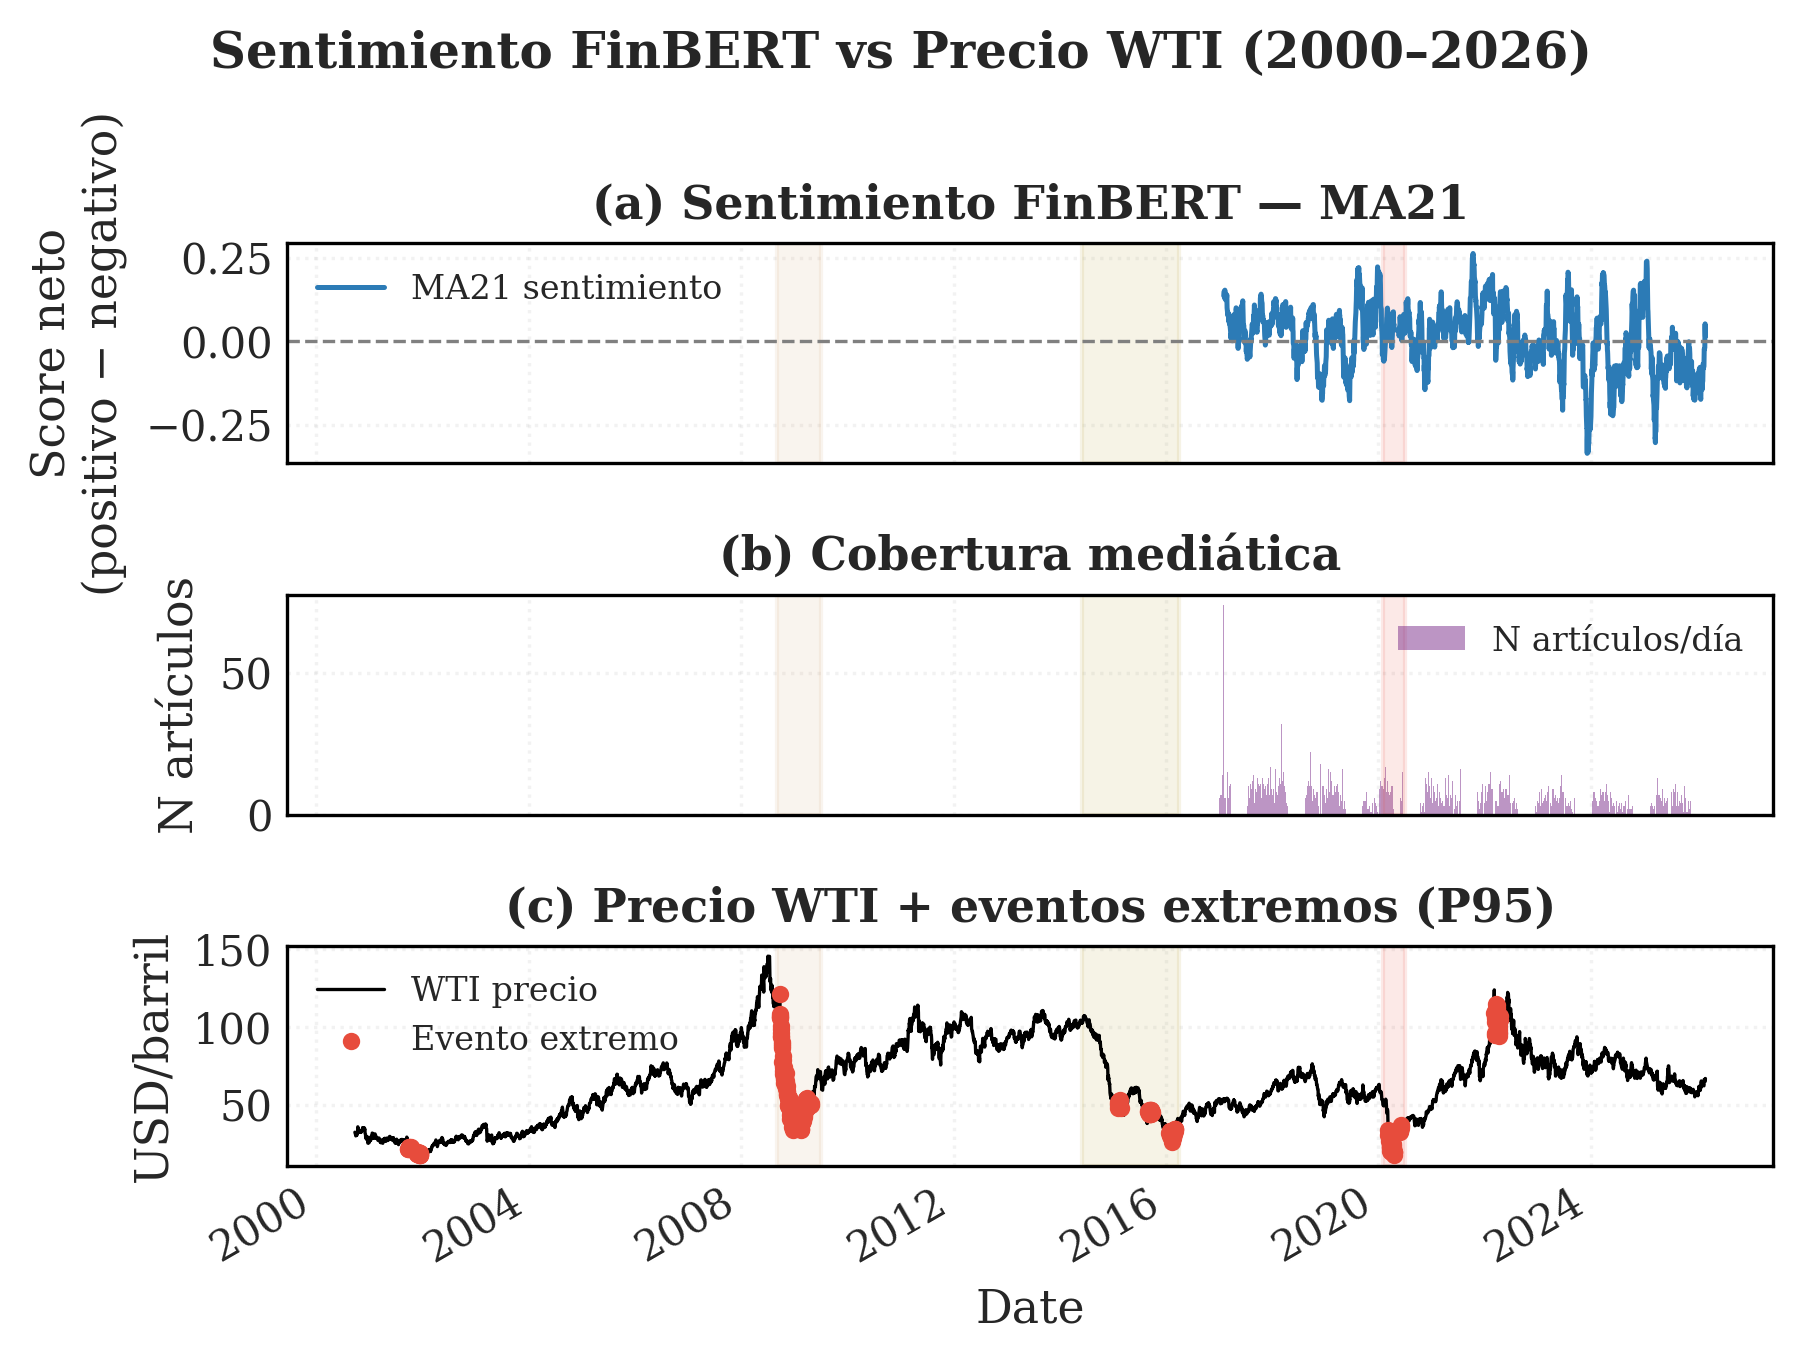

Figura guardada: fig_sentiment_timeseries.png


In [18]:
# ─── 7.1 Serie temporal de sentimiento ────────────────────────
fig, axes = plt.subplots(3, 1, figsize=fig_size("2x2"), sharex=True)

# Crisis zones — consistente con NB01/NB02
CRISIS = [
    ('2008-09-01', '2009-06-30', 'Crisis\n2008',   '#d4a574'),
    ('2014-06-01', '2016-03-31', 'Petróleo\n2014', '#b8a038'),
    ('2020-02-01', '2020-06-30', 'COVID-19',        '#e74c3c'),
]

def add_crisis(ax):
    for s, e, lbl, col in CRISIS:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.12, color=col)

# Panel (a): Sentimiento diario
axes[0].plot(daily.index, daily['sentiment_score'].rolling(21).mean(),
             color='#2c7bb6', lw=1.2, label='MA21 sentimiento')
axes[0].axhline(0, color='gray', ls='--', lw=0.8)
axes[0].set_ylabel('Score neto\n(positivo − negativo)')
axes[0].set_title('(a) Sentimiento FinBERT — MA21', fontweight='bold')
axes[0].legend(fontsize=8)
add_crisis(axes[0])

# Panel (b): Número de artículos
axes[1].bar(daily.index, daily['n_articles'], color='#7b2d8b',
            alpha=0.5, width=1, label='N artículos/día')
axes[1].set_ylabel('N artículos')
axes[1].set_title('(b) Cobertura mediática', fontweight='bold')
axes[1].legend(fontsize=8)
add_crisis(axes[1])

# Panel (c): WTI precio con extremos marcados
df_wti['wti_raw'].plot(ax=axes[2], color='black', lw=0.8, label='WTI precio')
extremos = df_wti[df_wti['is_extreme_clean'] == 1]
axes[2].scatter(extremos.index, extremos['wti_raw'],
                color='#e74c3c', s=10, zorder=5, label='Evento extremo')
axes[2].set_ylabel('USD/barril')
axes[2].set_title('(c) Precio WTI + eventos extremos (P95)', fontweight='bold')
axes[2].legend(fontsize=8)
add_crisis(axes[2])

fig.suptitle('Sentimiento FinBERT vs Precio WTI (2000–2026)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'{FIG_PATH}/fig_sentiment_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('Figura guardada: fig_sentiment_timeseries.png')

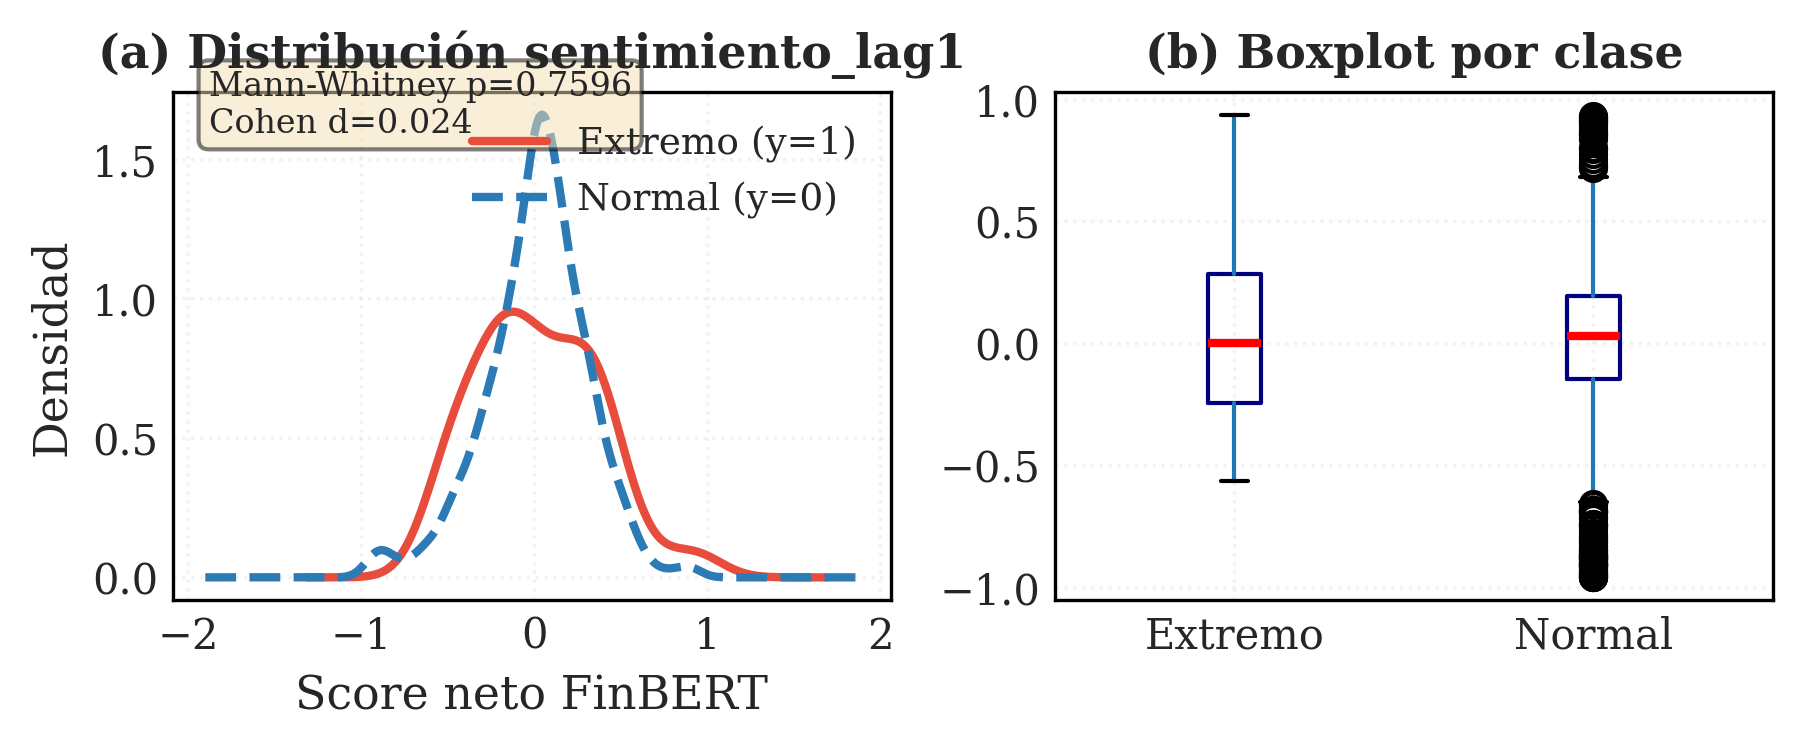

Días extremos con sentimiento: 66
Días normales con sentimiento: 2214
Media sentimiento — Extremo: 0.0203 | Normal: 0.0123
Mann-Whitney U: stat=71449.0, p=0.7596 (no significativo α=0.05)
Cohen's d: 0.024 (pequeño)


In [19]:
# ─── 7.2 Distribución sentimiento: extremos vs normales ───────
# Si el sentimiento es informativo, su distribución debe diferir
# entre días extremos y días normales.

df_analysis = df_wti[['is_extreme_clean']].join(
    daily[['sentiment_score_lag1', 'n_articles_lag1']], how='inner'
).dropna()

extremos_sent = df_analysis[df_analysis['is_extreme_clean'] == 1]['sentiment_score_lag1']
normales_sent = df_analysis[df_analysis['is_extreme_clean'] == 0]['sentiment_score_lag1']

from scipy import stats
import numpy as np

# 1. Protección de la estadística (Evitar división por cero)
if extremos_sent.nunique() > 1 and normales_sent.nunique() > 1:
    stat_mw, p_mw = stats.mannwhitneyu(extremos_sent, normales_sent, alternative='two-sided')
    pooled_std = np.sqrt((extremos_sent.std()**2 + normales_sent.std()**2) / 2)
    cohen_d = (extremos_sent.mean() - normales_sent.mean()) / pooled_std if pooled_std > 0 else 0.0
    p_text = f'Mann-Whitney p={p_mw:.4f}\nCohen d={cohen_d:.3f}'
else:
    stat_mw, p_mw, cohen_d = 0.0, 1.0, 0.0
    p_text = 'Estadísticas omitidas\n(Varianza cero)'

fig, axes = plt.subplots(1, 2, figsize=fig_size("wide"))

# 2. Protección Gráfica: KDE vs Histograma
if extremos_sent.nunique() > 1 and normales_sent.nunique() > 1:
    # Si hay varianza, usamos KDE
    extremos_sent.plot.kde(ax=axes[0], color='#e74c3c', label='Extremo (y=1)', lw=2)
    normales_sent.plot.kde(ax=axes[0], color='#2c7bb6', label='Normal (y=0)', lw=2, ls='--')
    axes[0].set_ylabel('Densidad')
else:
    # Si los valores son idénticos (ej. todos 0.0), el KDE explota. Usamos histograma.
    print("  [!] Aviso: KDE omitido porque los eventos extremos no tienen varianza (valores idénticos). Usando histograma.")
    extremos_sent.plot.hist(ax=axes[0], color='#e74c3c', alpha=0.5, label='Extremo (y=1)', density=True)
    normales_sent.plot.hist(ax=axes[0], color='#2c7bb6', alpha=0.5, label='Normal (y=0)', density=True)
    axes[0].set_ylabel('Frecuencia')

axes[0].set_title('(a) Distribución sentimiento_lag1', fontweight='bold')
axes[0].set_xlabel('Score neto FinBERT')
axes[0].legend(fontsize=9)
axes[0].text(0.05, 0.92,
             p_text,
             transform=axes[0].transAxes, fontsize=8,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Box plot
df_analysis = df_analysis.assign(
    clase=df_analysis['is_extreme_clean'].map({0: 'Normal', 1: 'Extremo'})
)
df_analysis.boxplot(column='sentiment_score_lag1', by='clase', ax=axes[1],
                    boxprops=dict(color='navy'),
                    medianprops=dict(color='red', lw=2))
axes[1].set_title('(b) Boxplot por clase', fontweight='bold')
axes[1].set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.savefig(f'{FIG_PATH}/fig_sentiment_dist.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Reporte en consola
print(f'Días extremos con sentimiento: {len(extremos_sent)}')
print(f'Días normales con sentimiento: {len(normales_sent)}')

if len(extremos_sent) < 5:
    print('⚠ Insuficientes días extremos con cobertura GDELT — '
          'posiblemente cobertura 2017+ no cubre suficientes eventos extremos de train.')

print(f'Media sentimiento — Extremo: {extremos_sent.mean():.4f} | '
      f'Normal: {normales_sent.mean():.4f}')

if p_mw != 1.0:
    print(f'Mann-Whitney U: stat={stat_mw:.1f}, p={p_mw:.4f} '
          f'({"*significativo" if p_mw < 0.05 else "no significativo"} α=0.05)')
    print(f"Cohen's d: {cohen_d:.3f} "
          f"({'grande' if abs(cohen_d)>0.8 else 'mediano' if abs(cohen_d)>0.5 else 'pequeño'})")

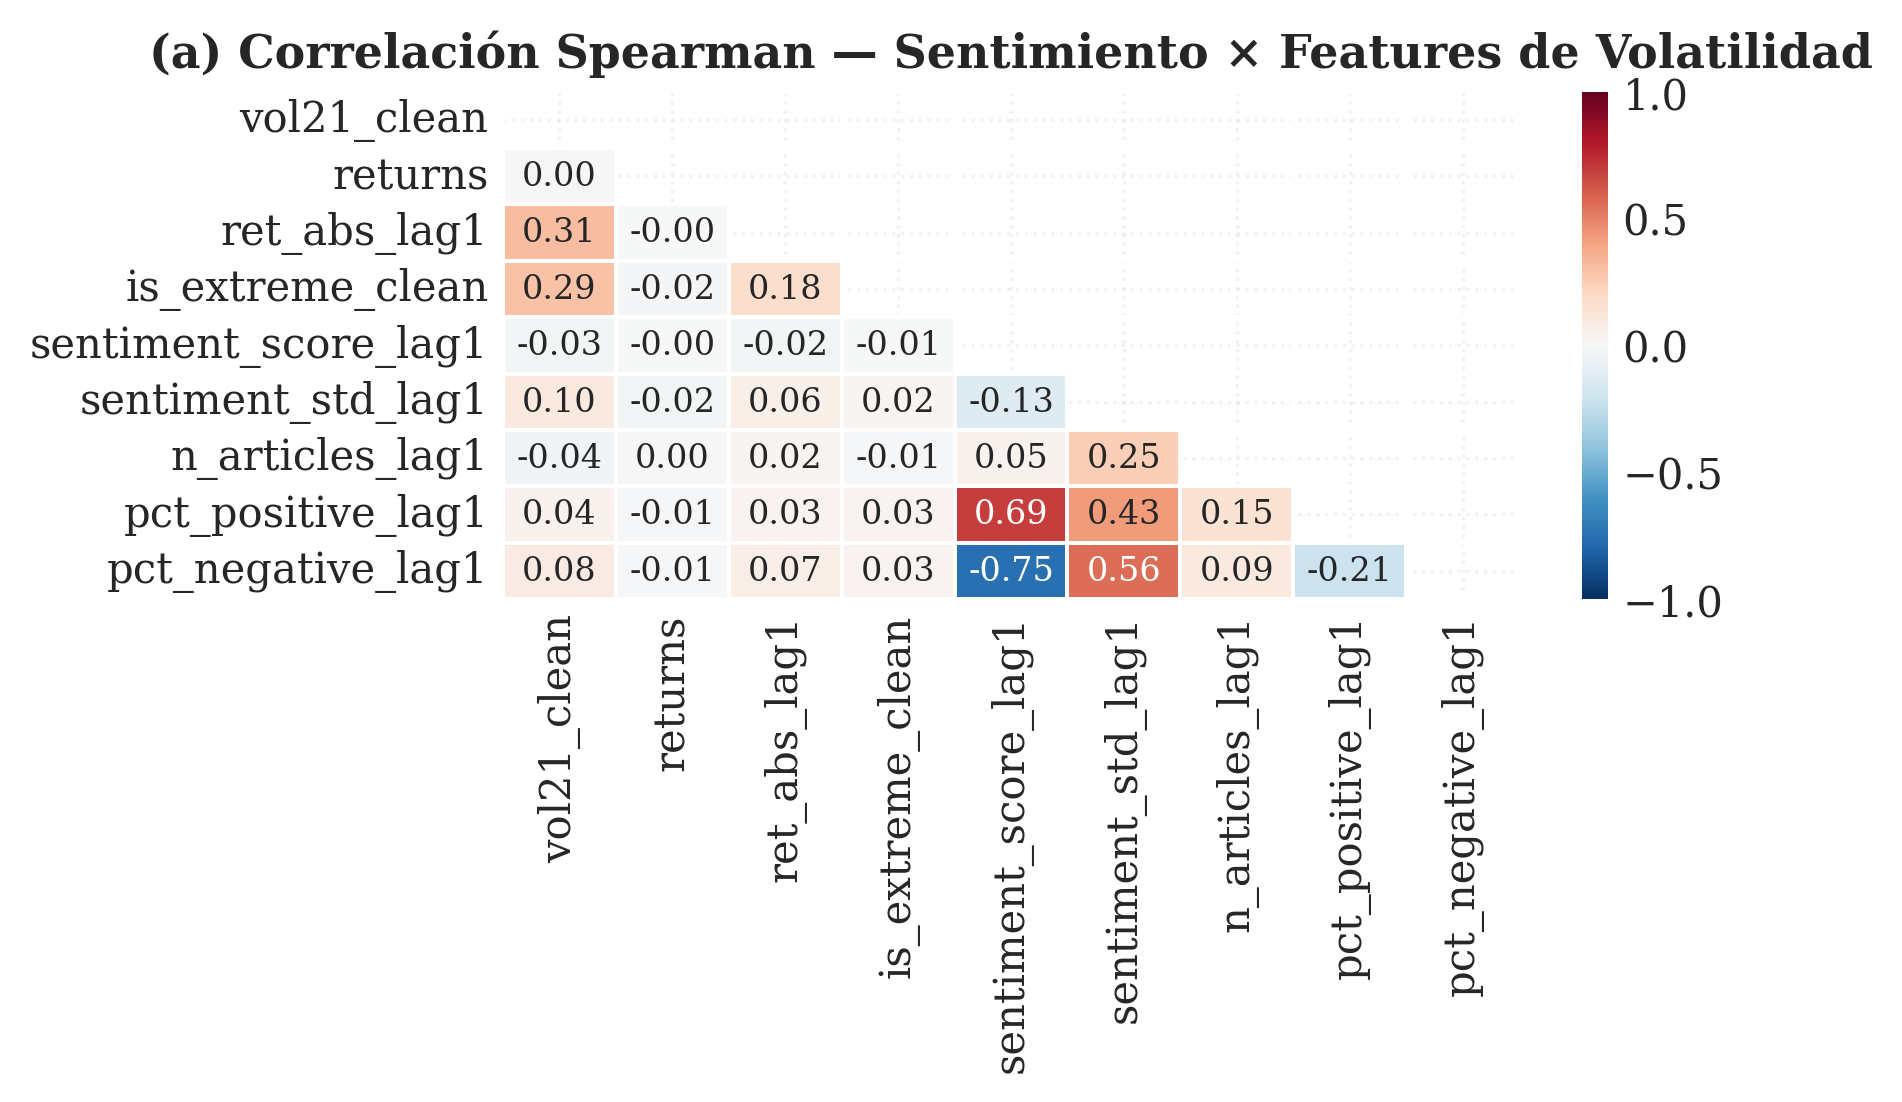

Figura guardada: fig_sentiment_corr.png

Correlación Spearman con is_extreme_clean:
  sentiment_score_lag1               : -0.0064
  sentiment_std_lag1                 : +0.0189
  n_articles_lag1                    : -0.0129
  pct_positive_lag1                  : +0.0300
  pct_negative_lag1                  : +0.0312


In [20]:
# ─── 7.3 Correlación sentimiento × features de volatilidad ────
SENT_FEATURES_LAG1 = [
    'sentiment_score_lag1',
    'sentiment_std_lag1',
    'n_articles_lag1',
    'pct_positive_lag1',
    'pct_negative_lag1',
]

df_corr = df_wti[['vol21_clean', 'returns', 'ret_abs_lag1',
                   'is_extreme_clean']].join(
    daily[SENT_FEATURES_LAG1], how='inner'
).dropna()

corr_mat = df_corr.corr(method='spearman')   # Spearman: robusto a outliers

fig, ax = plt.subplots(figsize=fig_size("full"))
mask = np.zeros_like(corr_mat, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('(a) Correlación Spearman — Sentimiento × Features de Volatilidad',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/fig_sentiment_corr.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('Figura guardada: fig_sentiment_corr.png')

# Correlación con el target
print('\nCorrelación Spearman con is_extreme_clean:')
for col in SENT_FEATURES_LAG1:
    r = df_corr[col].corr(df_corr['is_extreme_clean'], method='spearman')
    print(f'  {col:<35}: {r:+.4f}')

---
## PARTE VIII — Exportación

> El CSV exportado contiene **dos versiones** de las features de sentimiento:
> - `sentiment_score` (contemporáneo) → solo para diagnóstico / EDA
> - `sentiment_score_lag1` (rezagado 1 día) → el que **usa el modelo en NB02**
>
> NB02 Parte V carga este CSV y filtra las columnas `*_lag1`.

In [21]:
# ─── 8.1 Construir CSV final ──────────────────────────────────
# Columnas a exportar
EXPORT_COLS = [
    # Features contemporáneas (diagnóstico)
    'sentiment_score', 'sentiment_std', 'n_articles',
    'pct_positive', 'pct_negative', 'sentiment_flag',
    'sentiment_age_days', 'sentiment_low_coverage',
    # Features lag1 (para el modelo NB02)
    'sentiment_score_lag1', 'sentiment_std_lag1',
    'n_articles_lag1', 'pct_positive_lag1', 'pct_negative_lag1',
]

df_export = daily[EXPORT_COLS].copy()
df_export.index.name = 'Date'

# Integridad
assert df_export.index.is_monotonic_increasing, 'Índice no ordenado temporalmente'
assert not df_export['sentiment_score_lag1'].iloc[1:].isna().all(), \
    'sentiment_score_lag1 todo NaN — revisar shift'

print(f'Shape final: {df_export.shape}')
print(f'Período: {df_export.index.min().date()} → {df_export.index.max().date()}')
print(f'\nNaN por columna lag1:')
print(df_export[[c for c in EXPORT_COLS if 'lag1' in c]].isna().sum())

df_export.head(3)

Shape final: (6363, 13)
Período: 2000-09-22 → 2026-02-27

NaN por columna lag1:
sentiment_score_lag1    4083
sentiment_std_lag1      4083
n_articles_lag1         4083
pct_positive_lag1       4083
pct_negative_lag1       4083
dtype: int64


,sentiment_score,sentiment_std,n_articles,pct_positive,pct_negative,sentiment_flag,sentiment_age_days,sentiment_low_coverage,sentiment_score_lag1,sentiment_std_lag1,n_articles_lag1,pct_positive_lag1,pct_negative_lag1
Date,,,,,,,,,,,,,
2000-09-22,NaN,NaN,NaN,NaN,NaN,0,999,1,NaN,NaN,NaN,NaN,NaN
2000-09-25,NaN,NaN,NaN,NaN,NaN,0,999,1,NaN,NaN,NaN,NaN,NaN
2000-09-26,NaN,NaN,NaN,NaN,NaN,0,999,1,NaN,NaN,NaN,NaN,NaN


In [22]:
# =========================
# CELDA 8.2/8.3 (guardar CSV + persistir config nb03)
# =========================

# ─── 8.2 Guardar CSV ──────────────────────────────────────────
df_export.to_csv(OUTPUT_SENT, index=True)
print(f'CSV guardado: {OUTPUT_SENT}')
print(f'  Filas: {len(df_export):,}')
print(f'  Columnas: {list(df_export.columns)}')

# ─── 8.3 Actualizar config con metadata NB03 ──────────────────
with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    config_out = json.load(f)

config_out['nb03'] = {
    'fecha_ejecucion': datetime.now().isoformat(),
    'fuente_titulares': 'GDELT Project (gdeltdoc)',
    'modelo_sentimiento': 'ProsusAI/finbert',
    'n_titulares_totales': len(df),
    'n_dias_reales': n_real,
    'n_dias_imputados': n_imputed,
    'cobertura_pct': round(n_real / len(df_export) * 100, 2),
    'cobertura_split': split_coverage,
    'cobertura_anual_pct': {
        str(y): round(v * 100, 2) for y, v in coverage_year.items()
    },
    'anios_baja_cobertura': low_coverage_years,
    'umbral_baja_cobertura_pct': int(LOW_COVERAGE_THRESHOLD * 100),

    # >>> Campos clave para NB02 <<<
    'sentiment_usable_for_model': bool(SENTIMENT_USABLE_FOR_MODEL),
    'estado_modelo_hibrido': (
    'READY' if NB03_VALID_FOR_INFERENCE else 'SKIPPED_INSUFFICIENT_COVERAGE'
    ),
    'sentiment_usable_for_model': bool(NB03_VALID_FOR_INFERENCE),
    'nota_metodologica': (
        'Cobertura de sentimiento insuficiente en train/validation; no entrenar híbrido.'
        if not SENTIMENT_USABLE_FOR_MODEL else
        'Cobertura suficiente en train/validation para entrenar híbrido con features lag1.'
    ),

    'shift_aplicado': 'sentiment_score(t-1) → features en t',
    'features_lag1': [c for c in EXPORT_COLS if 'lag1' in c],
    'correlacion_target': {
        col: round(
            df_corr[col].corr(df_corr['is_extreme_clean'], method='spearman'),
            4
        )
        for col in SENT_FEATURES_LAG1
        if col in df_corr.columns
    },
    'validacion_predictiva_lag1': {
        'r_contemporaneo': round(r_contemp, 4),
        'r_lag1_target_t1': round(r_lag1, 4),
        'bootstrap_spearman_mediana': None if np.isnan(boot_med) else round(boot_med, 4),
        'bootstrap_spearman_ic95': [
            None if np.isnan(boot_lo) else round(boot_lo, 4),
            None if np.isnan(boot_hi) else round(boot_hi, 4),
        ],
    },
    'advertencias': [
        'Usar SOLO columnas *_lag1 en NB02 — las contemporáneas son para diagnóstico',
        'Días sin cobertura GDELT imputados con forward-fill (sentiment_flag=0)',
        'Cobertura GDELT débil antes de 2014 — monitorear correlación en train',
    ],
}

with open(CONFIG_PATH, 'w', encoding='utf-8') as f:
    json.dump(config_out, f, ensure_ascii=False, indent=2)

print('config_estudio_FINAL.json actualizado con nb03')
print(
    "Estado híbrido persistido en config: "
    f"{config_out['nb03']['estado_modelo_hibrido']} "
    f"(usable={config_out['nb03']['sentiment_usable_for_model']})"
)

CSV guardado: /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/NB03_FinBERT/wti_sentiment_finbert.csv
  Filas: 6,363
  Columnas: ['sentiment_score', 'sentiment_std', 'n_articles', 'pct_positive', 'pct_negative', 'sentiment_flag', 'sentiment_age_days', 'sentiment_low_coverage', 'sentiment_score_lag1', 'sentiment_std_lag1', 'n_articles_lag1', 'pct_positive_lag1', 'pct_negative_lag1']
config_estudio_FINAL.json actualizado con nb03
Estado híbrido persistido en config: READY (usable=True)


In [23]:
# ─── 8.4 Resumen final ────────────────────────────────────────
print('=' * 60)
print('NB03 COMPLETADO')
print('=' * 60)
print(f"""
FUENTE:       GDELT Project (ProsusAI/finbert)
TITULARES:    {len(df):,} headlines procesados
COBERTURA:    {n_real:,} días reales ({n_real/len(df_export)*100:.1f}%)
IMPUTADOS:    {n_imputed:,} días ffill

OUTPUT:
  {OUTPUT_SENT}

COLUMNAS PARA NB02 (Parte V):
  sentiment_score_lag1     — señal principal
  sentiment_std_lag1       — dispersión intradiaria
  n_articles_lag1          — atención mediática
  pct_positive_lag1        — fracción alcista
  pct_negative_lag1        — fracción bajista
  sentiment_flag           — 1=real, 0=imputado

ANTI-LEAKAGE VERIFICADO:
  El modelo usa sentiment(t-1) para predecir is_extreme(t+1)
  — ninguna columna *_lag1 contiene información del día t
""")
print(f'Fecha: {datetime.now().strftime("%Y-%m-%d %H:%M")}')

NB03 COMPLETADO

FUENTE:       GDELT Project (ProsusAI/finbert)
TITULARES:    16,781 headlines procesados
COBERTURA:    2,223 días reales (34.9%)
IMPUTADOS:    4,140 días ffill

OUTPUT:
  /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/NB03_FinBERT/wti_sentiment_finbert.csv

COLUMNAS PARA NB02 (Parte V):
  sentiment_score_lag1     — señal principal
  sentiment_std_lag1       — dispersión intradiaria
  n_articles_lag1          — atención mediática
  pct_positive_lag1        — fracción alcista
  pct_negative_lag1        — fracción bajista
  sentiment_flag           — 1=real, 0=imputado

ANTI-LEAKAGE VERIFICADO:
  El modelo usa sentiment(t-1) para predecir is_extreme(t+1)
  — ninguna columna *_lag1 contiene información del día t

Fecha: 2026-03-18 06:56


In [24]:
# --- 8.5 Requirements NB03 (reproducibilidad) ---
if IN_COLAB:
    import re

    def _update_req_section(req_path, section_id, header_comment, packages):
        import subprocess, re, os
        result = subprocess.run(["pip", "freeze"], capture_output=True, text=True)
        lines_found = sorted(set([
            l for l in result.stdout.splitlines()
            if any(l.lower().startswith(pkg.lower()) for pkg in packages)
        ]))
        try:
            with open(req_path, encoding="utf-8") as _f:
                content = _f.read()
        except FileNotFoundError:
            content = (
                "# =====================================================================\n"
                "# requirements.txt -- Proyecto WTI: Prediccion de Volatilidad\n"
                "# Entorno: Python 3.10+ (Google Colab)\n"
                "# Creado: " + datetime.now().strftime("%Y-%m-%d") + "\n"
                "# =====================================================================\n"
                "#\n"
                "# pip install -r requirements.txt   (instala todo)\n"
                "#\n"
            )
        sec_start = "# -- " + section_id + ": " + header_comment
        sec_end   = "# -- [END " + section_id + "]"
        nueva = (
            "\n" + sec_start + " (actualizado " + datetime.now().strftime("%Y-%m-%d") + ") --\n"
            + "\n".join(lines_found)
            + "\n" + sec_end + "\n"
        )
        patron = re.compile(
            re.escape("# -- " + section_id + ":") + r".*?" + re.escape(sec_end) + r"\n",
            re.DOTALL
        )
        content = patron.sub(nueva, content) if patron.search(content) else content + nueva
        os.makedirs(os.path.dirname(req_path) or ".", exist_ok=True)
        with open(req_path, "w", encoding="utf-8") as _f:
            _f.write(content)
        print("  [OK] requirements.txt -- seccion " + section_id + ": " + str(len(lines_found)) + " paquetes")
        for l in lines_found:
            print("       " + l)
        return lines_found

    REQ_PATH = f"{BASE_PATH}/requirements.txt"
    _update_req_section(
        req_path      = REQ_PATH,
        section_id    = "NB03",
        header_comment= "Sentimiento FinBERT (NLP)",
        packages      = [
            "torch", "transformers", "gdeltdoc",
            "huggingface-hub", "tokenizers",
        ]
    )
    print(f"  requirements.txt: {REQ_PATH}")


  [OK] requirements.txt -- seccion NB03: 11 paquetes
       gdeltdoc==1.5.0
       tokenizers==0.22.2
       torch==2.10.0+cu128
       torchao==0.10.0
       torchaudio==2.10.0+cu128
       torchcodec==0.10.0+cu128
       torchdata==0.11.0
       torchsummary==1.5.1
       torchtune==0.6.1
       torchvision==0.25.0+cu128
       transformers==5.0.0
  requirements.txt: /content/drive/My Drive/2410VDSO Trabajo de Grado/Modelos/requirements.txt
